**Formulating a Monte Carlo Simulation on AAPL's 1 year data**

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [44]:
start_date = "2025-01-01"
end_date = "2026-01-01"
ticker = 'AAPL'

df = yf.download(ticker,start_date,end_date)
df

/tmp/ipykernel_2490/3521818272.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker,start_date,end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.301926,247.518596,240.284814,247.349662,55740700
2025-01-03,241.815033,242.629819,240.354364,241.815033,40244100
2025-01-06,243.444626,245.759836,241.656050,242.759004,45045600
2025-01-07,240.672333,243.991125,239.817792,241.437433,40856000
2025-01-08,241.159225,242.162823,238.526055,240.384178,37628900
...,...,...,...,...,...
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600
2025-12-26,272.893005,274.859353,272.353998,273.651606,21521800


In [45]:
#next_price = current_price * e^(daily_return + volatility * random_shock)

In [46]:
random_shock = np.random.normal(0,1)

In [47]:
daily_returns = df['Close']['AAPL'].pct_change()
daily_returns

,AAPL
Date,
2025-01-02,NaN
2025-01-03,-0.002009
2025-01-06,0.006739
2025-01-07,-0.011388
2025-01-08,0.002023
...,...
2025-12-24,0.005324
2025-12-26,-0.001497
2025-12-29,0.001317


In [48]:
daily_returns.dropna(inplace=True)
daily_returns

,AAPL
Date,
2025-01-03,-0.002009
2025-01-06,0.006739
2025-01-07,-0.011388
2025-01-08,0.002023
2025-01-10,-0.024104
...,...
2025-12-24,0.005324
2025-12-26,-0.001497
2025-12-29,0.001317


In [49]:
volatility = daily_returns.std()
volatility

0.020450448911419544

In [50]:
daily_returns_mean = daily_returns.mean()
daily_returns_mean

np.float64(0.0006605118539277199)

In [51]:
next_price = df['Close']['AAPL'] * (np.exp(daily_returns + volatility * random_shock))
next_price.dropna(inplace=True)
next_price

,AAPL
Date,
2025-01-03,234.331630
2025-01-06,237.983701
2025-01-07,231.047263
2025-01-08,234.640400
2025-01-10,223.079509
...,...
2025-12-24,266.793688
2025-12-26,264.583315
2025-12-29,265.678305


In [52]:
last_price = df['Close']['AAPL'].iloc[-1]
num_simulations = 1000
num_days = 252
results = []

for i in range(num_simulations):
    prices = [last_price]
    for day in range(num_days):
        shock = np.random.normal(0, 1)
        next_p = prices[-1] * np.exp(daily_returns_mean + volatility * shock)
        prices.append(next_p)
    results.append(prices)

results = np.array(results)
results

array([[271.35583496, 268.82866572, 258.90437757, ..., 247.55368879,
        252.21358591, 254.35153237],
       [271.35583496, 278.13365195, 283.89137012, ..., 451.96319329,
        447.42776815, 441.33262947],
       [271.35583496, 268.32424412, 259.77512672, ..., 295.12872313,
        300.97150263, 297.96512441],
       ...,
       [271.35583496, 270.70196528, 267.0296553 , ..., 477.85480451,
        473.23500448, 460.63713303],
       [271.35583496, 276.51765589, 279.11766761, ..., 457.63061381,
        458.82693184, 457.21040971],
       [271.35583496, 268.91711956, 273.81952189, ..., 428.08533733,
        444.66926841, 430.5411267 ]])

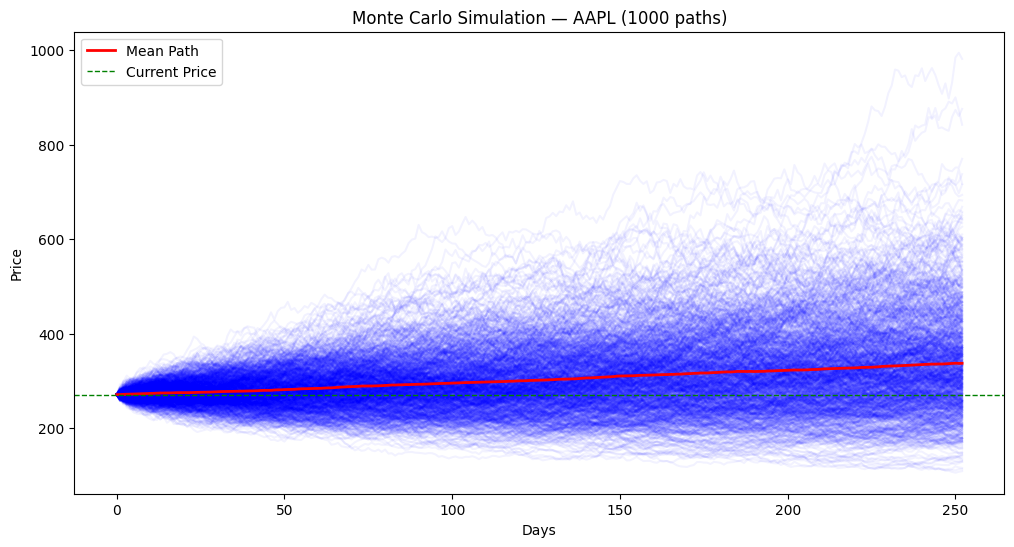

In [53]:
plt.figure(figsize=(12, 6))
for i in range(num_simulations):
    plt.plot(results[i], alpha=0.05, color='blue')

plt.plot(results.mean(axis=0), color='red', linewidth=2, label='Mean Path')
plt.axhline(y=last_price, color='green', linestyle='--', linewidth=1, label='Current Price')
plt.title('Monte Carlo Simulation — AAPL (1000 paths)')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

In [54]:
final_prices = results[:, -1]
print(f"5th percentile (worst case): ${np.percentile(final_prices, 5):.2f}")
print(f"Median outcome: ${np.percentile(final_prices, 50):.2f}")
print(f"95th percentile (best case): ${np.percentile(final_prices, 95):.2f}")

5th percentile (worst case): $185.54
Median outcome: $321.80
95th percentile (best case): $536.26


In [55]:
# Monte Carlo simulation models 1000 possible price paths for AAPL over 252 trading days
# based on historical return and volatility. Results show a median outcome of $315 (+16%),
# a worst case of $189 (-30%) at the 5th percentile, and a best case of $547 (+100%)
# at the 95th percentile — giving an investor a probabilistic range rather than a single forecast.